<h2>Let's Start </h2>
In this competition we have to predict the price of the houses. We have been given a lot of information about the houses. Here feature engineering is very important. We will see which features we should keep and which we should not and why. 

<h3> I would appreciate if you could upvote this kernel. </h3>

Importing required libraries.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import numpy as np  # linear algebra
import pandas as pd  #
from datetime import datetime

from scipy.stats import skew  # for some statistics
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

from mlxtend.regressor import StackingCVRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
random.seed(1)

Loading training and testing data.

In [2]:

train_data = pd.read_csv('../input/train.csv')
test_data = pd.read_csv('../input/test.csv')
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
Id               1460 non-null int64
MSSubClass       1460 non-null int64
MSZoning         1460 non-null object
LotFrontage      1201 non-null float64
LotArea          1460 non-null int64
Street           1460 non-null object
Alley            91 non-null object
LotShape         1460 non-null object
LandContour      1460 non-null object
Utilities        1460 non-null object
LotConfig        1460 non-null object
LandSlope        1460 non-null object
Neighborhood     1460 non-null object
Condition1       1460 non-null object
Condition2       1460 non-null object
BldgType         1460 non-null object
HouseStyle       1460 non-null object
OverallQual      1460 non-null int64
OverallCond      1460 non-null int64
YearBuilt        1460 non-null int64
YearRemodAdd     1460 non-null int64
RoofStyle        1460 non-null object
RoofMatl         1460 non-null object
Exterior1st      1460 non-n

Now we will check every feature which is not numerical. We will convert that feature to numerical value or drop that feature. I am taking all numerical features for training.

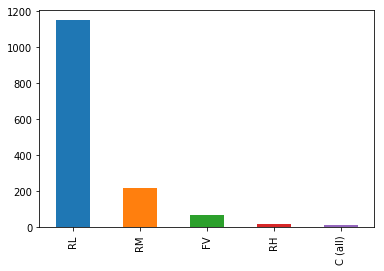

In [3]:
# Converting MSZoning to numerical
train_data.MSZoning.value_counts(dropna = False).plot.bar()
trans_dict = {'RL':0,'RM':1,'FV':2,'RH':3,'C (all)':4}
train_data.MSZoning = train_data.MSZoning.replace(trans_dict)
test_data.MSZoning = test_data.MSZoning.replace(trans_dict)

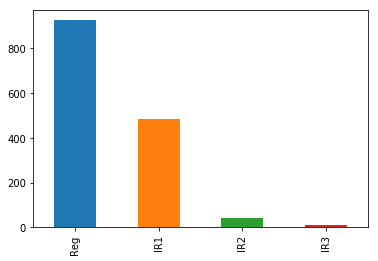

In [4]:
#converting LotShape to numerical
train_data.LotShape.value_counts(dropna = False).plot.bar()
trans_dict = {'Reg':0,'IR1':1,'IR2':2,'IR3':3}
train_data.LotShape = train_data.LotShape.replace(trans_dict)
test_data.LotShape = test_data.LotShape.replace(trans_dict)

This feature is very skewed but still I am taking it just for fun.

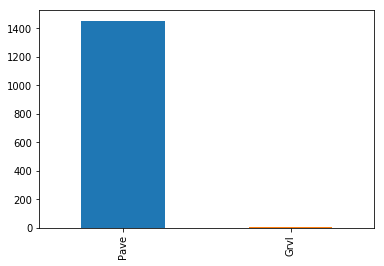

In [5]:
#converting Street to numerical
train_data.Street.value_counts(dropna = False).plot.bar()
trans_dict = {'Pave':0,'Grvl':1}
train_data.Street = train_data.Street.replace(trans_dict)
test_data.Street = test_data.Street.replace(trans_dict)


This feature has a lot of nan or null values. Therefore, I am dropping it. It is not usefull for our model.

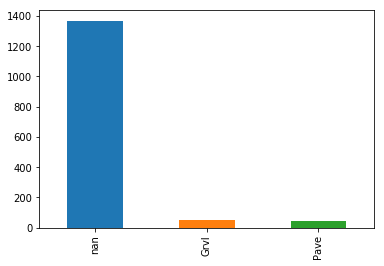

In [6]:
#Handling Alley , as it has lot of NaN we will drop it.
train_data.Alley.value_counts(dropna = False).plot.bar()
train_data.drop('Alley',inplace = True,axis = 1) 
test_data.drop('Alley',inplace = True,axis = 1) 

Here we just replaced values with numeric values so that we can easily work on it while training our model.

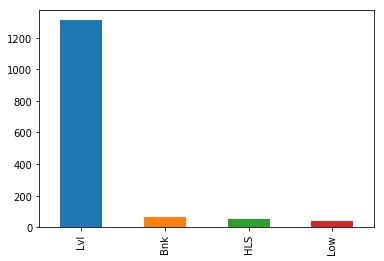

In [7]:
# Handling LandContour
train_data.LandContour.value_counts(dropna = False).plot.bar()
trans_dict = {'Lvl':0,'Bnk':1,'HLS':2,'Low':3}
train_data.LandContour = train_data.LandContour.replace(trans_dict)
test_data.LandContour = test_data.LandContour.replace(trans_dict)

This feature has a lot of skewness therefore I dropped it.

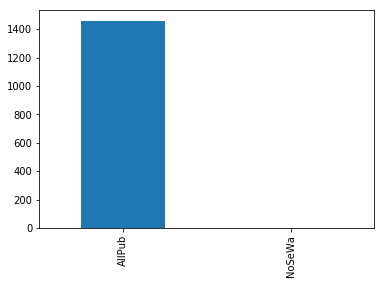

In [8]:
#Handling Utilities
train_data.Utilities.value_counts(dropna = False).plot.bar()
# as it has a lot of skewness towards the AllPub, we can drop it, it is not that important for the model.
train_data.drop('Utilities',inplace = True,axis = 1)
test_data.drop('Utilities',inplace = True,axis = 1)

This feature seems good. Replaced values with numeric.

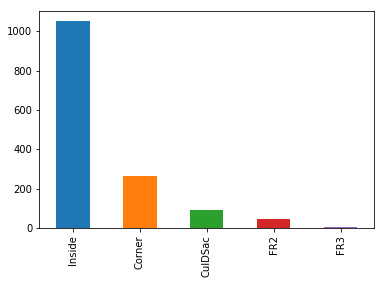

In [9]:
#Handling LotConfig
train_data.LotConfig.value_counts(dropna = False).plot.bar()
trans_dict = {'Inside':0,'Corner':1,'CulDSac':2,'FR2':3,'FR3':4}
train_data.LotConfig = train_data.LotConfig.replace(trans_dict)
test_data.LotConfig = test_data.LotConfig.replace(trans_dict)

This feature seems little skewed but still keep and replacing the values.

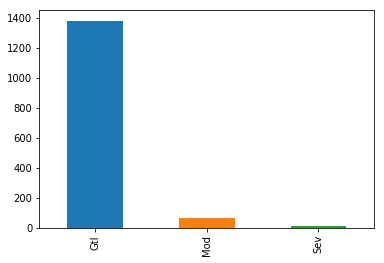

In [10]:
# Handling LandSlope
train_data.LandSlope.value_counts(dropna = False).plot.bar()
trans_dict = {'Gtl':0,'Mod':1,'Sev':2}
train_data.LandSlope = train_data.LandSlope.replace(trans_dict)
test_data.LandSlope = test_data.LandSlope.replace(trans_dict)

This feature is great to keep. Lot of categories. I have aloted a number to each category by using Label Encoder.

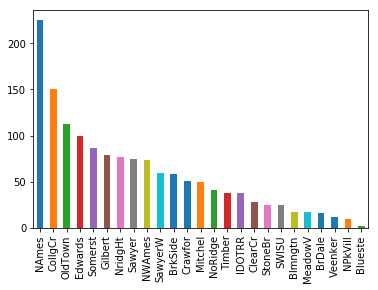

In [11]:
#Handling Neighborhood
train_data.Neighborhood.value_counts(dropna = False).plot.bar()
le = LabelEncoder()
train_data.Neighborhood = le.fit_transform(train_data.Neighborhood)
test_data.Neighborhood = le.transform(test_data.Neighborhood)


Keeping feature and aloted a number to each feature by using Label Encoder.

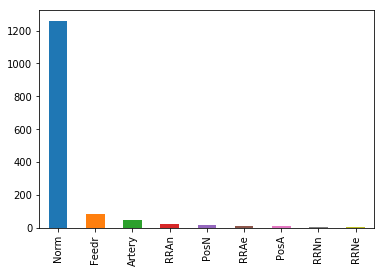

In [12]:
#Handling Condition1
train_data.Condition1.value_counts(dropna = False).plot.bar()
train_data.Condition1 = le.fit_transform(train_data.Condition1)
test_data.Condition1 = le.transform(test_data.Condition1)


This feature is skewed towards a single feature therefore it is of no use. Dropping it.

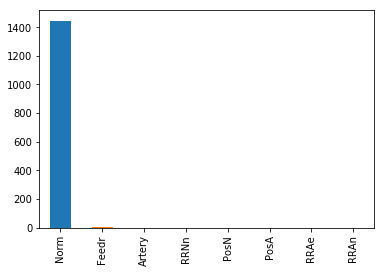

In [13]:
#Handling Condition2
train_data.Condition2.value_counts(dropna = False).plot.bar()
# very skewed therefore we can drop it
train_data.drop('Condition2',axis = 1,inplace = True)
test_data.drop('Condition2',axis = 1,inplace = True)


Using Label Encoder every category is given a number in the features.

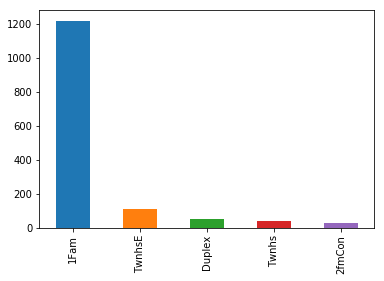

In [14]:
#Handling BldgType 
train_data.BldgType.value_counts(dropna = False).plot.bar()
train_data.BldgType = le.fit_transform(train_data.BldgType)
test_data.BldgType = le.transform(test_data.BldgType)


1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: HouseStyle, dtype: int64


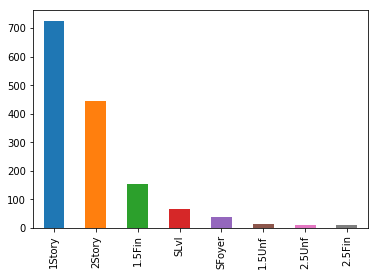

In [15]:
#Handling HouseStyle
print(train_data.HouseStyle.value_counts(dropna = False))
train_data.HouseStyle.value_counts(dropna = False).plot.bar()
train_data.HouseStyle = le.fit_transform(train_data.HouseStyle)
test_data.HouseStyle = le.transform(test_data.HouseStyle)


Gable      1141
Hip         286
Flat         13
Gambrel      11
Mansard       7
Shed          2
Name: RoofStyle, dtype: int64


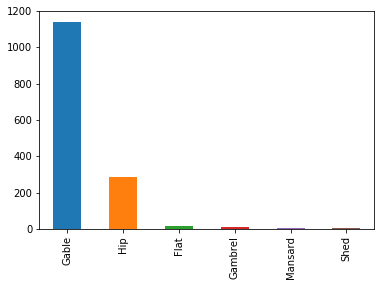

In [16]:
#Handling RoofStyle
print(train_data.RoofStyle.value_counts(dropna = False))
train_data.RoofStyle.value_counts(dropna = False).plot.bar()
train_data.RoofStyle = le.fit_transform(train_data.RoofStyle)
test_data.RoofStyle = le.transform(test_data.RoofStyle)


This feature is skewed therefore dropping it.

CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Membran       1
Roll          1
Metal         1
ClyTile       1
Name: RoofMatl, dtype: int64
Skewed towards a single feature : 0.9821917808219178


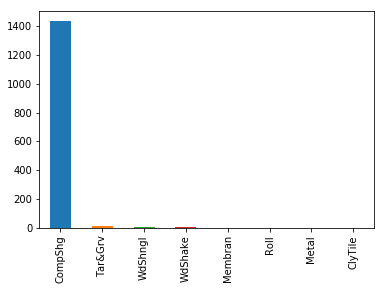

In [17]:
#Handling RoofMatl
print(train_data.RoofMatl.value_counts(dropna = False))
train_data.RoofMatl.value_counts(dropna = False).plot.bar()
print("Skewed towards a single feature :",train_data.RoofMatl.value_counts()[0]/len(train_data))
#very skewed therefore dropping it.
train_data.drop('RoofMatl',axis = 1,inplace = True)
test_data.drop('RoofMatl',axis = 1,inplace = True)


Good feature keeping it. Converting to numeric values.

VinylSd    515
HdBoard    222
MetalSd    220
Wd Sdng    206
Plywood    108
CemntBd     61
BrkFace     50
WdShing     26
Stucco      25
AsbShng     20
Stone        2
BrkComm      2
CBlock       1
AsphShn      1
ImStucc      1
Name: Exterior1st, dtype: int64
VinylSd    510
MetalSd    230
HdBoard    220
Wd Sdng    205
Plywood    113
CemntBd     65
BrkFace     37
WdShing     30
AsbShng     24
Stucco      18
BrkComm      4
CBlock       1
AsphShn      1
NaN          1
Name: Exterior1st, dtype: int64


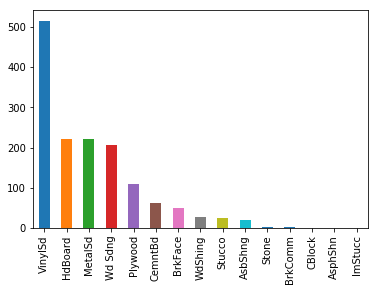

In [18]:
#Handling Exterior1st
print(train_data.Exterior1st.value_counts(dropna = False))
print(test_data.Exterior1st.value_counts(dropna = False))
train_data.Exterior1st.value_counts(dropna = False).plot.bar()
test_data.Exterior1st.fillna('VinylSd',inplace = True)
# there is a lot of values which are not in train but in test therefore drop it.
le = le.fit(train_data.Exterior1st.unique().tolist()+test_data.Exterior1st.unique().tolist())
train_data.Exterior1st = le.transform(train_data.Exterior1st)
test_data.Exterior1st = le.transform(test_data.Exterior1st)


VinylSd    504
MetalSd    214
HdBoard    207
Wd Sdng    197
Plywood    142
CmentBd     60
Wd Shng     38
Stucco      26
BrkFace     25
AsbShng     20
ImStucc     10
Brk Cmn      7
Stone        5
AsphShn      3
CBlock       1
Other        1
Name: Exterior2nd, dtype: int64
VinylSd    510
MetalSd    233
HdBoard    199
Wd Sdng    194
Plywood    128
CmentBd     66
Wd Shng     43
BrkFace     22
Stucco      21
AsbShng     18
Brk Cmn     15
ImStucc      5
CBlock       2
AsphShn      1
Stone        1
NaN          1
Name: Exterior2nd, dtype: int64


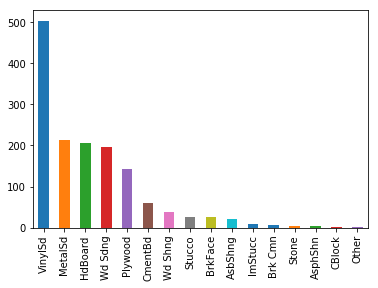

In [19]:
#Handling Exterior2nd
print(train_data.Exterior2nd.value_counts(dropna = False))
print(test_data.Exterior2nd.value_counts(dropna = False))
train_data.Exterior2nd.value_counts(dropna = False).plot.bar()
test_data.Exterior2nd.fillna('VinylSd',inplace = True)  #filling the nan or null values in test data
le = le.fit(train_data.Exterior2nd.unique().tolist()+test_data.Exterior2nd.unique().tolist())
train_data.Exterior2nd = le.transform(train_data.Exterior2nd)
test_data.Exterior2nd = le.transform(test_data.Exterior2nd)


None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: MasVnrType, dtype: int64
None       878
BrkFace    434
Stone      121
NaN         16
BrkCmn      10
Name: MasVnrType, dtype: int64


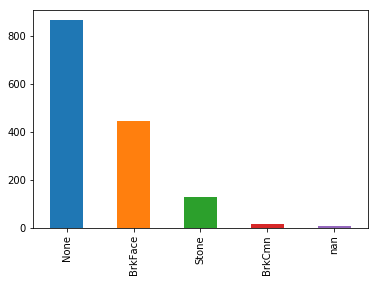

In [20]:
#Handling MasVnrType
print(train_data.MasVnrType.value_counts(dropna = False))
print(test_data.MasVnrType.value_counts(dropna = False))
train_data.MasVnrType.value_counts(dropna = False).plot.bar()
test_data.MasVnrType.fillna('None',inplace = True)
train_data.MasVnrType.fillna('None',inplace = True)
le = le.fit(train_data.MasVnrType.unique().tolist()+test_data.MasVnrType.unique().tolist())
train_data.MasVnrType = le.transform(train_data.MasVnrType)
test_data.MasVnrType = le.transform(test_data.MasVnrType)



TA    906
Gd    488
Ex     52
Fa     14
Name: ExterQual, dtype: int64
TA    892
Gd    491
Ex     55
Fa     21
Name: ExterQual, dtype: int64


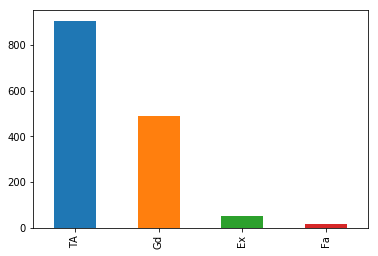

In [21]:
#Handling ExterQual
print(train_data.ExterQual.value_counts(dropna = False))
print(test_data.ExterQual.value_counts(dropna = False))
train_data.ExterQual.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.ExterQual.unique().tolist())
train_data.ExterQual = le.transform(train_data.ExterQual)
test_data.ExterQual = le.transform(test_data.ExterQual)


TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: ExterCond, dtype: int64
TA    1256
Gd     153
Fa      39
Ex       9
Po       2
Name: ExterCond, dtype: int64


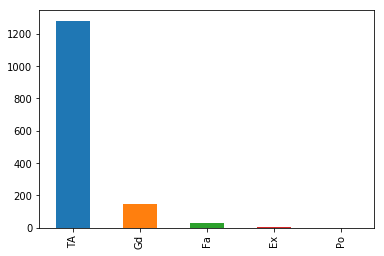

In [22]:
#Handling ExterCond
print(train_data.ExterCond.value_counts(dropna = False))
print(test_data.ExterCond.value_counts(dropna = False))
train_data.ExterCond.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.ExterCond.unique().tolist())
train_data.ExterCond = le.transform(train_data.ExterCond)
test_data.ExterCond = le.transform(test_data.ExterCond)


PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: Foundation, dtype: int64
PConc     661
CBlock    601
BrkTil    165
Slab       25
Stone       5
Wood        2
Name: Foundation, dtype: int64


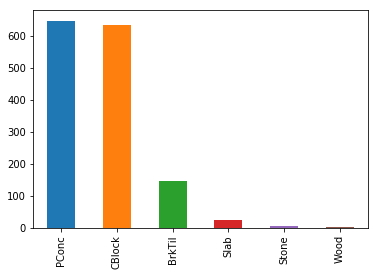

In [23]:
#Handling Foundation
print(train_data.Foundation.value_counts(dropna = False))
print(test_data.Foundation.value_counts(dropna = False))
train_data.Foundation.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.Foundation.unique().tolist())
train_data.Foundation = le.transform(train_data.Foundation)
test_data.Foundation = le.transform(test_data.Foundation)



TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: BsmtQual, dtype: int64
TA     634
Gd     591
Ex     137
Fa      53
NaN     44
Name: BsmtQual, dtype: int64


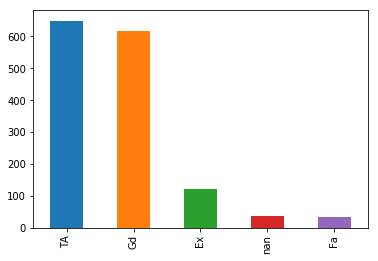

In [24]:
#Handling BsmtQual
print(train_data.BsmtQual.value_counts(dropna = False))
print(test_data.BsmtQual.value_counts(dropna = False))
train_data.BsmtQual.value_counts(dropna = False).plot.bar()
test_data.BsmtQual.fillna('TA',inplace = True)
train_data.BsmtQual.fillna('TA',inplace = True)
le = le.fit(train_data.BsmtQual.unique().tolist())
train_data.BsmtQual = le.transform(train_data.BsmtQual)
test_data.BsmtQual = le.transform(test_data.BsmtQual)




TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: BsmtCond, dtype: int64
TA     1295
Fa       59
Gd       57
NaN      45
Po        3
Name: BsmtCond, dtype: int64


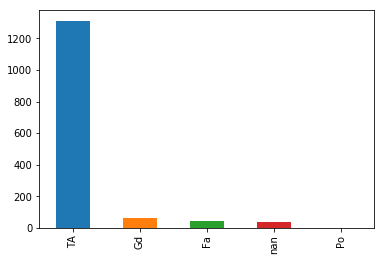

In [25]:
#Handling BsmtCond
print(train_data.BsmtCond.value_counts(dropna = False))
print(test_data.BsmtCond.value_counts(dropna = False))
train_data.BsmtCond.value_counts(dropna = False).plot.bar()
test_data.BsmtCond.fillna('TA',inplace = True)
train_data.BsmtCond.fillna('TA',inplace = True)
le = le.fit(train_data.BsmtCond.unique().tolist())
train_data.BsmtCond = le.transform(train_data.BsmtCond)
test_data.BsmtCond = le.transform(test_data.BsmtCond)



No     953
Av     221
Gd     134
Mn     114
NaN     38
Name: BsmtExposure, dtype: int64
No     951
Av     197
Gd     142
Mn     125
NaN     44
Name: BsmtExposure, dtype: int64


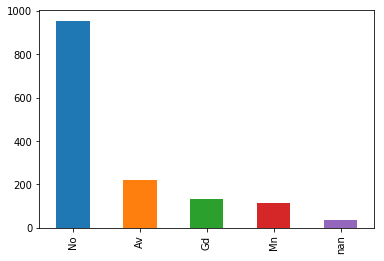

In [26]:
#Handling BsmtExposure
print(train_data.BsmtExposure.value_counts(dropna = False))
print(test_data.BsmtExposure.value_counts(dropna = False))
train_data.BsmtExposure.value_counts(dropna = False).plot.bar()
test_data.BsmtExposure.fillna('No',inplace = True)
train_data.BsmtExposure.fillna('No',inplace = True)
le = le.fit(train_data.BsmtExposure.unique().tolist())
train_data.BsmtExposure = le.transform(train_data.BsmtExposure)
test_data.BsmtExposure = le.transform(test_data.BsmtExposure)




Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
NaN     37
Name: BsmtFinType1, dtype: int64
GLQ    431
Unf    421
ALQ    209
Rec    155
BLQ    121
LwQ     80
NaN     42
Name: BsmtFinType1, dtype: int64


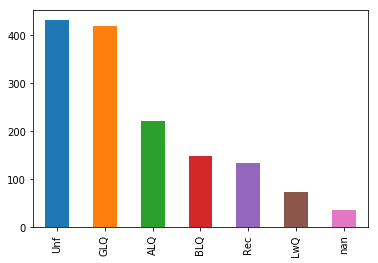

In [27]:
#Handling BsmtFinType1
print(train_data.BsmtFinType1.value_counts(dropna = False))
print(test_data.BsmtFinType1.value_counts(dropna = False))
train_data.BsmtFinType1.value_counts(dropna = False).plot.bar()
test_data.BsmtFinType1.fillna('GLQ',inplace = True)
train_data.BsmtFinType1.fillna('Unf',inplace = True)
le = le.fit(train_data.BsmtFinType1.unique().tolist())
train_data.BsmtFinType1 = le.transform(train_data.BsmtFinType1)
test_data.BsmtFinType1 = le.transform(test_data.BsmtFinType1)



Unf    1256
Rec      54
LwQ      46
NaN      38
BLQ      33
ALQ      19
GLQ      14
Name: BsmtFinType2, dtype: int64
Unf    1237
Rec      51
NaN      42
LwQ      41
BLQ      35
ALQ      33
GLQ      20
Name: BsmtFinType2, dtype: int64


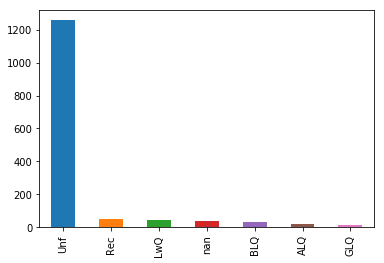

In [28]:
#Handling BsmtFinType2
print(train_data.BsmtFinType2.value_counts(dropna = False))
print(test_data.BsmtFinType2.value_counts(dropna = False))
train_data.BsmtFinType2.value_counts(dropna = False).plot.bar()
test_data.BsmtFinType2.fillna('Unf',inplace = True)
train_data.BsmtFinType2.fillna('Unf',inplace = True)
le = le.fit(train_data.BsmtFinType2.unique().tolist())
train_data.BsmtFinType2 = le.transform(train_data.BsmtFinType2)
test_data.BsmtFinType2 = le.transform(test_data.BsmtFinType2)




GasA     1428
GasW       18
Grav        7
Wall        4
OthW        2
Floor       1
Name: Heating, dtype: int64
GasA    1446
GasW       9
Wall       2
Grav       2
Name: Heating, dtype: int64


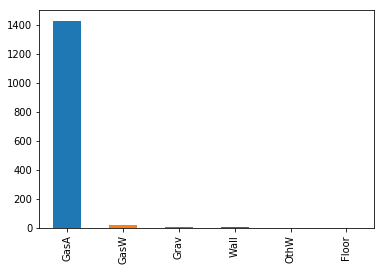

In [29]:
#Handling Heating
print(train_data.Heating.value_counts(dropna = False))
print(test_data.Heating.value_counts(dropna = False))
train_data.Heating.value_counts(dropna = False).plot.bar()
#very skewed therefore drop it.
test_data.drop('Heating',axis = 1,inplace = True)
train_data.drop('Heating',axis = 1,inplace = True)




Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: HeatingQC, dtype: int64
Ex    752
TA    429
Gd    233
Fa     43
Po      2
Name: HeatingQC, dtype: int64


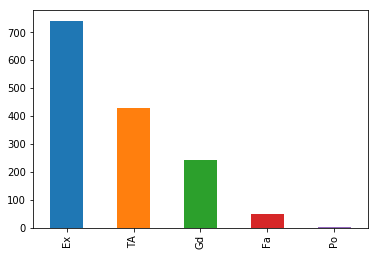

In [30]:
#Handling HeatingQC
print(train_data.HeatingQC.value_counts(dropna = False))
print(test_data.HeatingQC.value_counts(dropna = False))
train_data.HeatingQC.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.HeatingQC.unique().tolist())
train_data.HeatingQC = le.transform(train_data.HeatingQC)
test_data.HeatingQC = le.transform(test_data.HeatingQC)




Y    1365
N      95
Name: CentralAir, dtype: int64
Y    1358
N     101
Name: CentralAir, dtype: int64


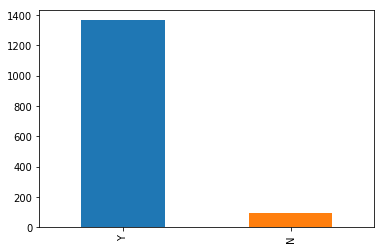

In [31]:
#Handling CentralAir
print(train_data.CentralAir.value_counts(dropna = False))
print(test_data.CentralAir.value_counts(dropna = False))
train_data.CentralAir.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.CentralAir.unique().tolist())
train_data.CentralAir = le.transform(train_data.CentralAir)
test_data.CentralAir = le.transform(test_data.CentralAir)




SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
NaN         1
Name: Electrical, dtype: int64
SBrkr    1337
FuseA      94
FuseF      23
FuseP       5
Name: Electrical, dtype: int64


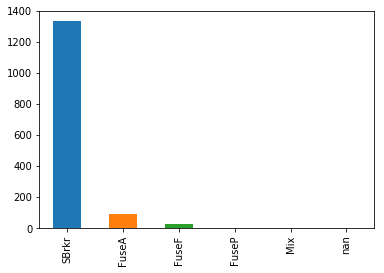

In [32]:
#Handling Electrical
print(train_data.Electrical.value_counts(dropna = False))
print(test_data.Electrical.value_counts(dropna = False))
train_data.Electrical.value_counts(dropna = False).plot.bar()
#very skewed therefore we can drop it.
train_data.drop('Electrical',axis = 1,inplace = True)
test_data.drop('Electrical',axis = 1,inplace = True)




TA    735
Gd    586
Ex    100
Fa     39
Name: KitchenQual, dtype: int64
TA     757
Gd     565
Ex     105
Fa      31
NaN      1
Name: KitchenQual, dtype: int64


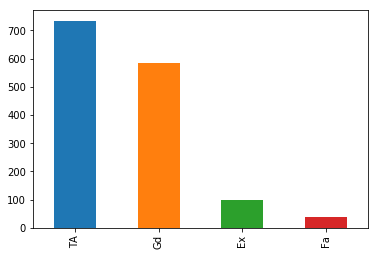

In [33]:
#Handling KitchenQual
print(train_data.KitchenQual.value_counts(dropna = False))
print(test_data.KitchenQual.value_counts(dropna = False))
train_data.KitchenQual.value_counts(dropna = False).plot.bar()
test_data.KitchenQual.fillna('TA',inplace = True)
le = le.fit(train_data.KitchenQual.unique().tolist())
train_data.KitchenQual = le.transform(train_data.KitchenQual)
test_data.KitchenQual = le.transform(test_data.KitchenQual)




Typ     1360
Min2      34
Min1      31
Mod       15
Maj1      14
Maj2       5
Sev        1
Name: Functional, dtype: int64
Typ     1357
Min2      36
Min1      34
Mod       20
Maj1       5
Maj2       4
NaN        2
Sev        1
Name: Functional, dtype: int64


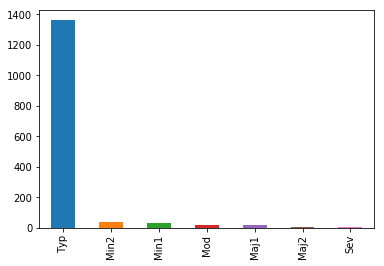

In [34]:
#Handling Functional
print(train_data.Functional.value_counts(dropna = False))
print(test_data.Functional.value_counts(dropna = False))
train_data.Functional.value_counts(dropna = False).plot.bar()
#very skewed therefore we can drop it.
train_data.drop('Functional',axis = 1,inplace = True)
test_data.drop('Functional',axis = 1,inplace = True)




NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: FireplaceQu, dtype: int64
NaN    730
Gd     364
TA     279
Fa      41
Po      26
Ex      19
Name: FireplaceQu, dtype: int64


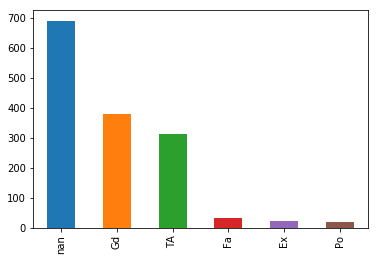

In [35]:
#Handling FireplaceQu
print(train_data.FireplaceQu.value_counts(dropna = False))
print(test_data.FireplaceQu.value_counts(dropna = False))
train_data.FireplaceQu.value_counts(dropna = False).plot.bar()
test_data.FireplaceQu.fillna('None',inplace = True)
train_data.FireplaceQu.fillna('None',inplace = True)
le = le.fit(train_data.FireplaceQu.unique().tolist())
train_data.FireplaceQu = le.transform(train_data.FireplaceQu)
test_data.FireplaceQu = le.transform(test_data.FireplaceQu)




Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64
Attchd     853
Detchd     392
BuiltIn     98
NaN         76
Basment     17
2Types      17
CarPort      6
Name: GarageType, dtype: int64


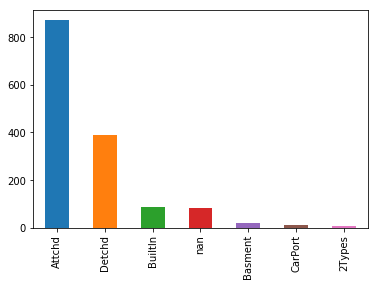

In [36]:
#Handling GarageType
print(train_data.GarageType.value_counts(dropna = False))
print(test_data.GarageType.value_counts(dropna = False))
train_data.GarageType.value_counts(dropna = False).plot.bar()
test_data.GarageType.fillna('Attchd',inplace = True)
train_data.GarageType.fillna('Attchd',inplace = True)
le = le.fit(train_data.GarageType.unique().tolist())
train_data.GarageType = le.transform(train_data.GarageType)
test_data.GarageType = le.transform(test_data.GarageType)




Unf    605
RFn    422
Fin    352
NaN     81
Name: GarageFinish, dtype: int64
Unf    625
RFn    389
Fin    367
NaN     78
Name: GarageFinish, dtype: int64


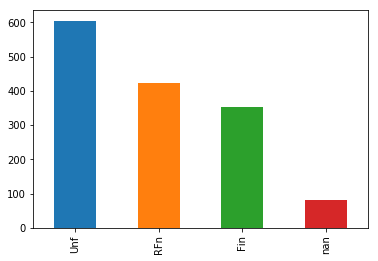

In [37]:
#Handling GarageFinish
print(train_data.GarageFinish.value_counts(dropna = False))
print(test_data.GarageFinish.value_counts(dropna = False))
train_data.GarageFinish.value_counts(dropna = False).plot.bar()
test_data.GarageFinish.fillna('None',inplace = True) # filling nan or null values with None
train_data.GarageFinish.fillna('None',inplace = True) # filling nan or null values with None
le = le.fit(train_data.GarageFinish.unique().tolist())
train_data.GarageFinish = le.transform(train_data.GarageFinish)
test_data.GarageFinish = le.transform(test_data.GarageFinish)




TA     1311
NaN      81
Fa       48
Gd       14
Po        3
Ex        3
Name: GarageQual, dtype: int64
TA     1293
NaN      78
Fa       76
Gd       10
Po        2
Name: GarageQual, dtype: int64


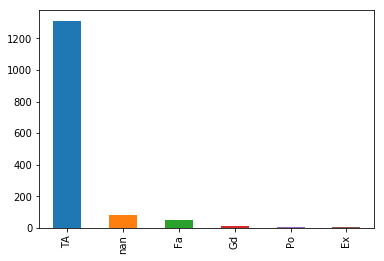

In [38]:
#Handling GarageQual
print(train_data.GarageQual.value_counts(dropna = False))
print(test_data.GarageQual.value_counts(dropna = False))
train_data.GarageQual.value_counts(dropna = False).plot.bar()
#very skewed we can drop it.
train_data.drop('GarageQual',axis = 1,inplace = True)
test_data.drop('GarageQual',axis = 1,inplace = True)



TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: GarageCond, dtype: int64
TA     1328
NaN      78
Fa       39
Po        7
Gd        6
Ex        1
Name: GarageCond, dtype: int64


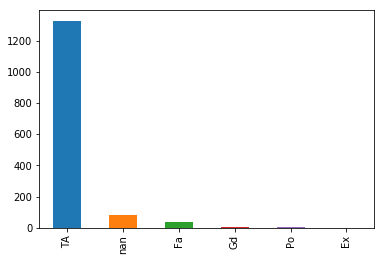

In [39]:
#Handling GarageCond
print(train_data.GarageCond.value_counts(dropna = False))
print(test_data.GarageCond.value_counts(dropna = False))
train_data.GarageCond.value_counts(dropna = False).plot.bar()
#very skewed we can drop it.
train_data.drop('GarageCond',axis = 1,inplace = True)
test_data.drop('GarageCond',axis = 1,inplace = True)


Y    1340
N      90
P      30
Name: PavedDrive, dtype: int64
Y    1301
N     126
P      32
Name: PavedDrive, dtype: int64


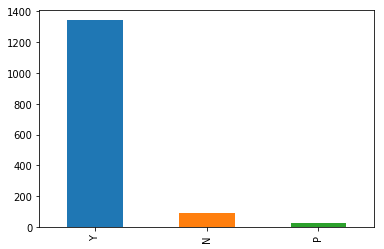

In [40]:
#Handling PavedDrive
print(train_data.PavedDrive.value_counts(dropna = False))
print(test_data.PavedDrive.value_counts(dropna = False))
train_data.PavedDrive.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.PavedDrive.unique().tolist())
train_data.PavedDrive = le.transform(train_data.PavedDrive)
test_data.PavedDrive = le.transform(test_data.PavedDrive)


NaN    1453
Gd        3
Fa        2
Ex        2
Name: PoolQC, dtype: int64
NaN    1456
Ex        2
Gd        1
Name: PoolQC, dtype: int64


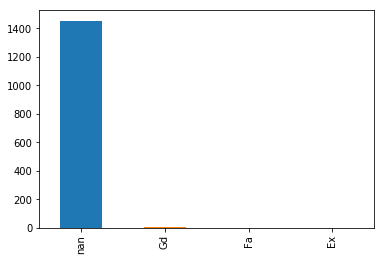

In [41]:
#Handling PoolQC
print(train_data.PoolQC.value_counts(dropna = False))
print(test_data.PoolQC.value_counts(dropna = False))
train_data.PoolQC.value_counts(dropna = False).plot.bar()
#too much NaN values we can drop it.
train_data.drop('PoolQC',axis = 1,inplace = True)
test_data.drop('PoolQC',axis = 1,inplace = True)


NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: Fence, dtype: int64
NaN      1169
MnPrv     172
GdPrv      59
GdWo       58
MnWw        1
Name: Fence, dtype: int64


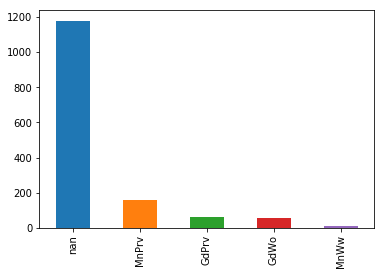

In [42]:
#Handling Fence
print(train_data.Fence.value_counts(dropna = False))
print(test_data.Fence.value_counts(dropna = False))
train_data.Fence.value_counts(dropna = False).plot.bar()
#too much NaN values we can drop it.
train_data.drop('Fence',axis = 1,inplace = True)
test_data.drop('Fence',axis = 1,inplace = True)


NaN     1406
Shed      49
Othr       2
Gar2       2
TenC       1
Name: MiscFeature, dtype: int64
NaN     1408
Shed      46
Gar2       3
Othr       2
Name: MiscFeature, dtype: int64


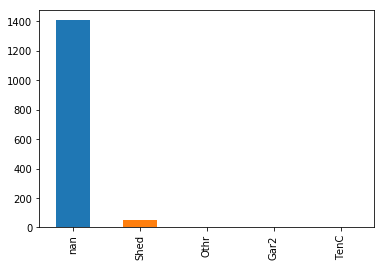

In [43]:
#Handling MiscFeature
print(train_data.MiscFeature.value_counts(dropna = False))
print(test_data.MiscFeature.value_counts(dropna = False))
train_data.MiscFeature.value_counts(dropna = False).plot.bar()
#too much NaN values we can drop it.
train_data.drop('MiscFeature',axis = 1,inplace = True)
test_data.drop('MiscFeature',axis = 1,inplace = True)


WD       1267
New       122
COD        43
ConLD       9
ConLw       5
ConLI       5
CWD         4
Oth         3
Con         2
Name: SaleType, dtype: int64
WD       1258
New       117
COD        44
ConLD      17
CWD         8
Oth         4
ConLI       4
ConLw       3
Con         3
NaN         1
Name: SaleType, dtype: int64


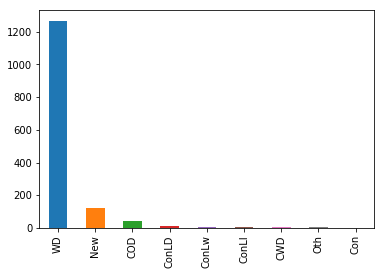

In [44]:
#Handling SaleType
print(train_data.SaleType.value_counts(dropna = False))
print(test_data.SaleType.value_counts(dropna = False))
train_data.SaleType.value_counts(dropna = False).plot.bar()
#very skewed we can drop it.
train_data.drop('SaleType',axis = 1,inplace = True)
test_data.drop('SaleType',axis = 1,inplace = True)


Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: SaleCondition, dtype: int64
Normal     1204
Partial     120
Abnorml      89
Family       26
Alloca       12
AdjLand       8
Name: SaleCondition, dtype: int64


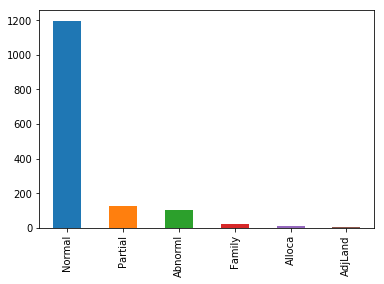

In [45]:
#Handling SaleCondition
print(train_data.SaleCondition.value_counts(dropna = False))
print(test_data.SaleCondition.value_counts(dropna = False))
train_data.SaleCondition.value_counts(dropna = False).plot.bar()
le = le.fit(train_data.SaleCondition.unique().tolist())
train_data.SaleCondition = le.transform(train_data.SaleCondition)
test_data.SaleCondition = le.transform(test_data.SaleCondition)


In [46]:
#Let's get the shape of our data to know number of features and samples
train_data.shape

(1460, 68)

In [47]:
#Let's get our X_train and y_train
X_train = train_data.drop(['SalePrice'],axis = 1)
y_train = train_data['SalePrice']
X_train.fillna(method = 'ffill',inplace = True)

In [48]:
#Let's prepare our training and testing data
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size = 0.2)

In [49]:
#preparing data for lightgbm
lgb_train = lgb.Dataset(X_train,y_train)
lgb_test = lgb.Dataset(X_test,y_test)

In [50]:
#Let's set parameters for our model
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': {'rmse'},
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}


In [51]:
#training our lightgbm model
model = lgb.train(params,lgb_train,num_boost_round=10000,valid_sets=lgb_test,early_stopping_rounds=100)

[1]	valid_0's rmse: 79719.3
Training until validation scores don't improve for 100 rounds.
[2]	valid_0's rmse: 79142.2
[3]	valid_0's rmse: 78535.2
[4]	valid_0's rmse: 77934.3
[5]	valid_0's rmse: 77340.8
[6]	valid_0's rmse: 76767.9
[7]	valid_0's rmse: 76199.9
[8]	valid_0's rmse: 75640.1
[9]	valid_0's rmse: 75093.8
[10]	valid_0's rmse: 74544.5
[11]	valid_0's rmse: 74006
[12]	valid_0's rmse: 73458.1
[13]	valid_0's rmse: 72929.2
[14]	valid_0's rmse: 72405.3
[15]	valid_0's rmse: 71887.9
[16]	valid_0's rmse: 71373.1
[17]	valid_0's rmse: 70865.2
[18]	valid_0's rmse: 70330.9
[19]	valid_0's rmse: 69831.9
[20]	valid_0's rmse: 69340
[21]	valid_0's rmse: 68832.5
[22]	valid_0's rmse: 68337.6
[23]	valid_0's rmse: 67840.6
[24]	valid_0's rmse: 67351.3
[25]	valid_0's rmse: 66867.7
[26]	valid_0's rmse: 66397.1
[27]	valid_0's rmse: 65938.3
[28]	valid_0's rmse: 65488.9
[29]	valid_0's rmse: 65039.7
[30]	valid_0's rmse: 64598.3
[31]	valid_0's rmse: 64087.9
[32]	valid_0's rmse: 63589.4
[33]	valid_0's rmse: 6

In [52]:
test_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleCondition
0,1461,20,3.0,80.0,11622,0,0,0,0,0,12,1,0,2,5,6,1961,1961,1,12,13,2,0.0,3,4,1,3,3,3,4,468.0,3,144.0,270.0,882.0,4,1,896,0,0,896,0.0,0.0,1,0,2,1,3,5,0,3,1,1961.0,3,1.0,730.0,2,140,0,0,0,120,0,0,6,2010,4
1,1462,20,0.0,81.0,14267,0,1,0,1,0,12,2,0,2,6,6,1958,1958,3,13,14,1,108.0,3,4,1,3,3,3,0,923.0,5,0.0,406.0,1329.0,4,1,1329,0,0,1329,0.0,0.0,1,1,3,1,2,6,0,3,1,1958.0,3,1.0,312.0,2,393,36,0,0,0,0,12500,6,2010,4
2,1463,60,0.0,74.0,13830,0,1,0,0,0,8,2,0,5,5,5,1997,1998,1,12,13,2,0.0,3,4,2,2,3,3,2,791.0,5,0.0,137.0,928.0,2,1,928,701,0,1629,0.0,0.0,2,1,3,1,3,6,1,5,1,1997.0,0,2.0,482.0,2,212,34,0,0,0,0,0,3,2010,4
3,1464,60,0.0,78.0,9978,0,1,0,0,0,8,2,0,5,6,6,1998,1998,1,12,13,1,20.0,3,4,2,3,3,3,2,602.0,5,0.0,324.0,926.0,0,1,926,678,0,1604,0.0,0.0,2,1,3,1,2,7,1,2,1,1998.0,0,2.0,470.0,2,360,36,0,0,0,0,0,6,2010,4
4,1465,120,0.0,43.0,5005,0,1,2,0,0,22,2,4,2,8,5,1992,1992,1,6,6,2,0.0,2,4,2,2,3,3,0,263.0,5,0.0,1017.0,1280.0,0,1,1280,0,0,1280,0.0,0.0,2,0,2,1,2,5,0,3,1,1992.0,2,2.0,506.0,2,0,82,0,0,144,0,0,1,2010,4


In [53]:
test_data.fillna(method = 'ffill',inplace = True)
pred = model.predict(test_data)
sample = pd.read_csv('../input/sample_submission.csv')
sample['SalePrice'] = pred
sample.to_csv('sub.csv',index = False)
sample.head()

,Id,SalePrice
0,1461,124395.494907
1,1462,159496.234829
2,1463,177085.795771
3,1464,185037.236621
4,1465,192048.580767


**Hope you like it. I would appreciate if you could upvote this kernel and let me know in the comments if you have any suggestion or question.**